In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_boston
boston = load_boston()
print(boston.keys())
print(boston.data.shape)
print(boston.DESCR)

dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])
(506, 13)
.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
   

1

In [3]:
from sklearn.model_selection import train_test_split
X = boston.data
y = boston.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=20)
print(X.shape[0])
print(float(X_train.shape[0]) / float(X.shape[0]))
print(float(X_test.shape[0]) / float(X.shape[0]))

506
0.7984189723320159
0.2015810276679842


2

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn import linear_model

regr = linear_model.LinearRegression()
 
# Learning model on training data
regr.fit(X_train, y_train)
Y_pred = regr.predict(X_test)

Text(0.5, 1.0, 'Prices vs Predicted prices: $Y_i$ vs $\\hat{Y}_i$')

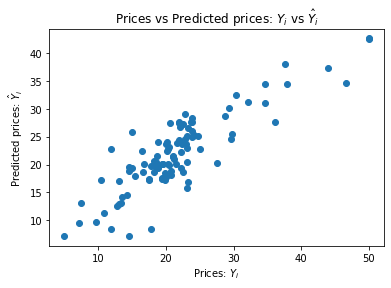

In [5]:
plt.scatter(y_test, Y_pred)
plt.xlabel("Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title("Prices vs Predicted prices: $Y_i$ vs $\hat{Y}_i$")

3,4

obliczenie mse

In [6]:
def mse(y_test,Y_pred):
    return np.sum((y_test-Y_pred)**2)/len(y_test)

print(mse(y_test,Y_pred))
print(len(y_test))

16.495351975931715
102


Biorąc pod uwagę ilość danych MSE wydaje się nie małe, ale i nie duże

In [7]:
from sklearn import preprocessing

scale=preprocessing.StandardScaler()
new_X=scale.fit_transform(X_train)
new_X_test=scale.transform(X_test)


polynomial features

In [8]:
from sklearn.preprocessing import PolynomialFeatures
 
polynomial_features= PolynomialFeatures(degree=2)
poly_X=polynomial_features.fit_transform(new_X)
poly_Xt=polynomial_features.transform(new_X_test)


In [9]:
pregr = linear_model.LinearRegression()
 
pregr.fit(poly_X, y_train)

Y_pred = pregr.predict(poly_Xt)
print(mse(y_test,Y_pred))

18.873365520402498


5

wykresy alpha/MSE dla Lasso

Text(0, 0.5, 'MSE')

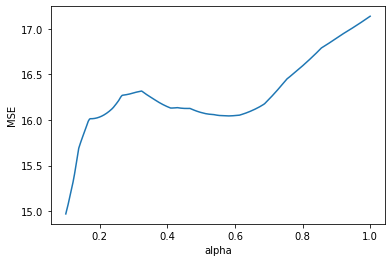

In [10]:
a=np.linspace(0.1,1,800)
mean=[]
for i in a:
    poly_X=polynomial_features.fit_transform(new_X)
    poly_Xt=polynomial_features.transform(new_X_test)

    pregr = linear_model.Lasso(alpha=i)
    
    pregr.fit(poly_X, y_train)

    Y_pred = pregr.predict(poly_Xt)
    mean.append(mse(y_test,Y_pred))

plt.plot(a,mean)
plt.xlabel('alpha')
plt.ylabel('MSE')

Text(0, 0.5, 'MSE')

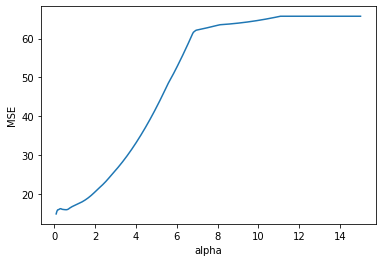

In [11]:
a=np.linspace(0.1,15,400)
mean=[]
for i in a:
    pregr = linear_model.Lasso(alpha=i)
    
    pregr.fit(poly_X, y_train)

    Y_pred = pregr.predict(poly_Xt)
    mean.append(mse(y_test,Y_pred))

plt.plot(a,mean)
plt.xlabel('alpha')
plt.ylabel('MSE')

6

wykres alpha/MSE dla Ridge

Text(0, 0.5, 'MSE')

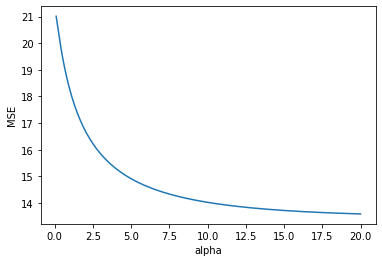

In [12]:
a=np.linspace(0.1,20,200)
mean=[]
for i in a:
    pregr = linear_model.Ridge(alpha=i)
    
    pregr.fit(poly_X, y_train)

    Y_pred = pregr.predict(poly_Xt)
    mean.append(mse(y_test,Y_pred))

plt.plot(a,mean)
plt.xlabel('alpha')
plt.ylabel('MSE')

Regularization for logistic regression

A

In [33]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
 
df = pd.DataFrame(data.data)
df.columns = data.feature_names
y = data.target
X=data.data
print(df.columns)
'''Preparing test, train sets'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=20)
scale=preprocessing.StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)



Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


Text(0, 0.5, 'accuracy')

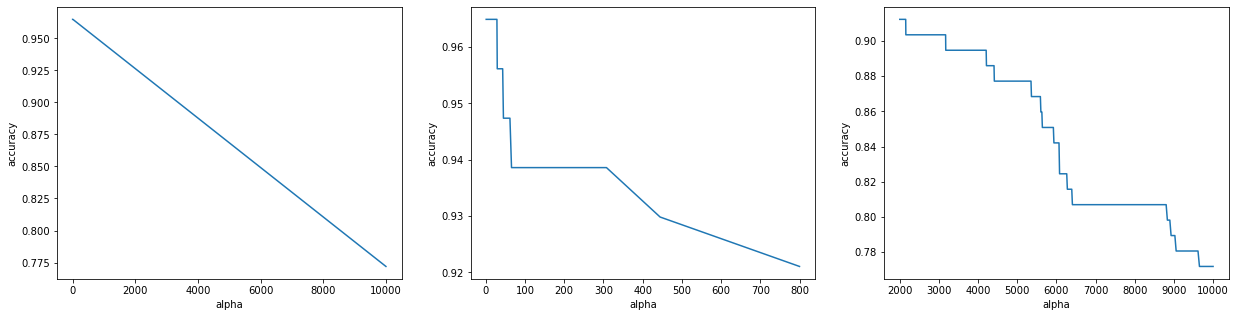

In [37]:
c=np.linspace(0.0001, 1,10)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)

    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(21,5))
ax1.plot(1/c,acc)
ax1.set_xlabel('alpha')
ax1.set_ylabel('accuracy')

c=np.linspace(0.0001, 0.0005,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)

    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))

ax3.plot(1/c,acc)
ax3.set_xlabel('alpha')
ax3.set_ylabel('accuracy')

c=np.linspace(0.00125, 1,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)

    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))
    
ax2.plot(1/c,acc)
ax2.set_xlabel('alpha')
ax2.set_ylabel('accuracy')



B

In [141]:
path = 'https://uu-sml.github.io/course-sml-public/data/biopsy.csv'
dataset = pd.read_csv(path, na_values='?', dtype={'ID': str})
dataset.columns = ['ID', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']

wrought=dataset.fillna(dataset.mean()).drop('ID',axis=1)
y=np.where(dataset['Class']=='malignant',1,0)
x=wrought.drop('Class',axis=1)

Text(0, 0.5, 'accuracy')

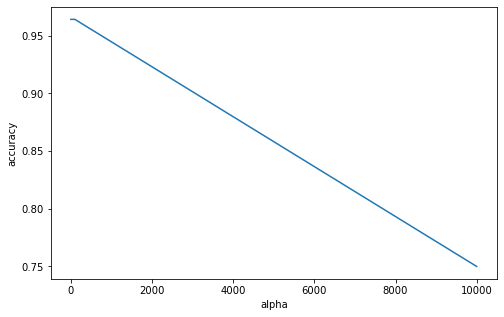

In [172]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=20)
scale=preprocessing.StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)



c=np.linspace(0.0001, 10,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)
    
    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))

fig, (ax1) = plt.subplots(1, 1,figsize=(8,5))
ax1.plot(1/c,acc)
ax1.set_xlabel('alpha')
ax1.set_ylabel('accuracy')

Tu nie c a alpha

Text(0, 0.5, 'accuracy')

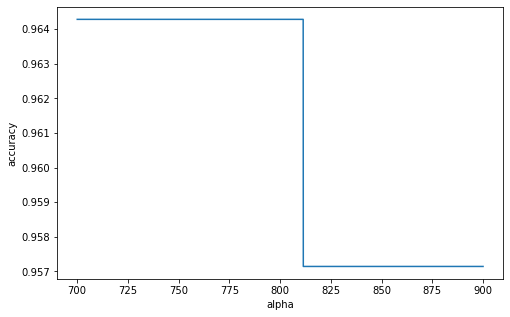

In [170]:
a=np.linspace(700, 900,10000)
acc=[]
for i in a:
    pregr = linear_model.Ridge(alpha=i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)
    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))
fig, (ax1) = plt.subplots(1, 1,figsize=(8,5))
ax1.plot(a,acc)
ax1.set_xlabel('alpha')
ax1.set_ylabel('accuracy')

Znowu c

Text(0, 0.5, 'accuracy')

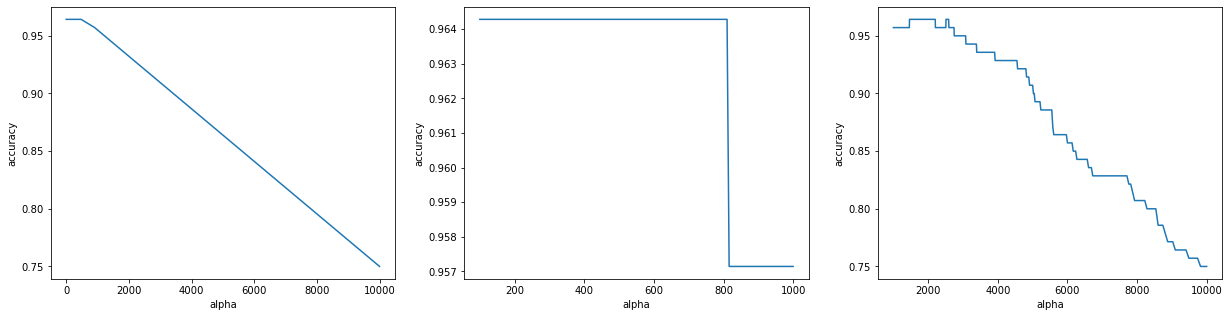

In [155]:
c=np.linspace(0.0001, 1,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)
    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(21,5))
ax1.plot(1/c,acc)
ax1.set_xlabel('alpha')
ax1.set_ylabel('accuracy')

c=np.linspace(0.0001, 0.001,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)
    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))
ax3.plot(1/c,acc)
ax3.set_xlabel('alpha')
ax3.set_ylabel('accuracy')

c=np.linspace(0.001, 0.01,1000)
acc=[]
for i in c:
    pregr = linear_model.Ridge(alpha=1/i)
    
    pregr.fit(X_train, y_train)

    Y_pred = pregr.predict(X_test)
    acc.append(np.sum(y_test==(Y_pred>=0.5))/len(y_test))
ax2.plot(1/c,acc)
ax2.set_xlabel('alpha')
ax2.set_ylabel('accuracy')
